# Квантовый оптимальный контроль создание ЭПР состояния сепарабельного когерентного состояния под дейсвием гамильтониана ZZ

In [17]:
import math
from datetime import timedelta

In [23]:
import numpy as np
import qutip
from qutip.control.pulseoptim import optimize_pulse_unitary
from tqdm import tqdm
import matplotlib.pyplot as plt

In [3]:
import pathlib
import sys

sys.path.append(str(pathlib.Path(sys.path[0]).parent / "libs"))

In [4]:
%reload_ext autoreload
%autoreload 2

import bec
from tools.qutip import TqdmProgressBar

In [5]:
n = 2
n_bosons = 3
phase = 0  # np.pi / 4
# model = BEC_Qubits.init_alexey2003(n_bosons=n_bosons, phase=phase)
model = bec.BEC_Qubits.init_default(n_bosons=n_bosons, phase=phase)

In [25]:
psi_target = bec.epr_plus_state_constructor(model, n=n) * bec.vacuum_state(model, n=n)

In [7]:
qutip.entropy.entropy_vn(qutip.ptrace(epr_state, [0, 1])) / math.log(model.n_bosons + 1)

1.0000000000000002

In [9]:
state_initial = (
    bec.coherent_state_constructor(model, n=2, k=0)
    * bec.coherent_state_constructor(model, n=2, k=1)
    * bec.vacuum_state(model, n=2)
)

## Сравнение с ZZ

In [8]:
hzz = bec.sz(model, n=2, k=0) *  bec.sz(model, n=2, k=1)

In [61]:
tspan_wide = np.linspace(0, 3, 301)
hzz_evolution_span_wide = qutip.sesolve(
    hzz,
    state_initial,
    tspan_wide,
    progress_bar=TqdmProgressBar()
)

100%|██████████| 301/301 [00:00<00:00, 6411.19it/s]


In [62]:
fidelity_epr2zz_span_wide = [qutip.metrics.fidelity(s, psi_target) for s in tqdm(hzz_evolution_span_wide.states)]

100%|██████████| 301/301 [00:00<00:00, 41103.22it/s]


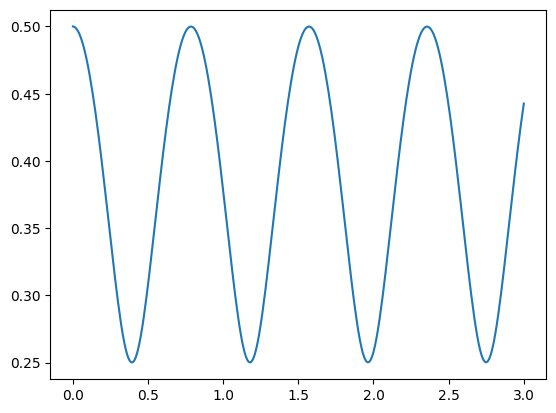

In [64]:
plt.plot(tspan_wide, fidelity_epr2zz_span_wide)
# plt.plot([t_target, t_target], [np.min(fidelity_epr2zz_span_wide), np.max(fidelity_epr2zz_span_wide)])

## Сравнение с XY

In [65]:
hxy = bec.sx(model, n=2, k=0) * bec.sx(model, n=2, k=1) - bec.sy(
    model, n=2, k=0
) * bec.sy(model, n=2, k=1)

In [70]:
tspan_wide = np.linspace(0, 1, 101)
hxy_evolution_span_wide = qutip.sesolve(
    hxy,
    state_initial,
    tspan_wide,
    progress_bar=TqdmProgressBar()
)

100%|██████████| 101/101 [00:00<00:00, 4964.60it/s]


In [71]:
fidelity_epr2xy_span_wide = [qutip.metrics.fidelity(s, psi_target) for s in tqdm(hxy_evolution_span_wide.states)]

100%|██████████| 101/101 [00:00<00:00, 41511.48it/s]


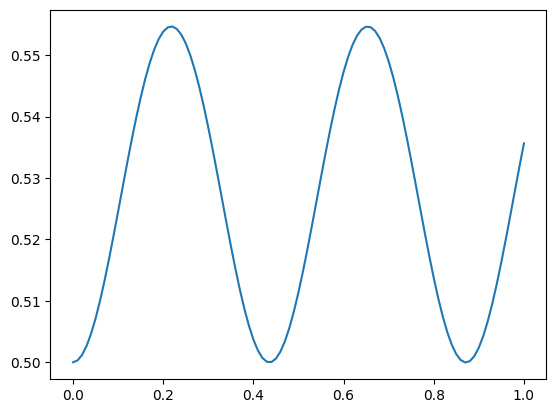

In [72]:
plt.plot(tspan_wide, fidelity_epr2xy_span_wide)
# plt.plot([t_target, t_target], [np.min(fidelity_epr2zz_span_wide), np.max(fidelity_epr2zz_span_wide)])

## Оптимальный контроль

In [83]:
n_ts = 101
t_target = 0.2
tspan = np.linspace(0, t_target, n_ts)

In [84]:
H_d = hzz
H_c = [hzz]

In [85]:
fid_err_targ = 1e-2
max_iter = 500
max_wall_time = timedelta(minutes=2).seconds
# max_wall_time = timedelta(hours=2).seconds
# pulse type alternatives: RND|ZERO|LIN|SINE|SQUARE|SAW|TRIANGLE|
p_type = "SINE"

In [86]:
%%time

min_grad = 1e-5

result_grape = optimize_pulse_unitary(
    H_d,
    H_c,
    state_initial,
    psi_target,
    n_ts,
    tspan,
    fid_err_targ=fid_err_targ,
    max_iter=max_iter,
    max_wall_time=max_wall_time,
    min_grad=min_grad,
    init_pulse_type=p_type,
    gen_stats=True,
)  # or use `optimize_pulse` with  dyn_type='UNIT'

result_grape.fidelity, result_grape.fid_err

CPU times: user 17min 45s, sys: 53.2 s, total: 18min 38s
Wall time: 2min 41s


(0.0, 0.5155408576317051)

In [87]:
result_grape.stats.report()


------------------------------------
---- Control optimisation stats ----
**** Timings (HH:MM:SS.US) ****
Total wall time elapsed during optimisation: 0:02:41.408950
Wall time computing Hamiltonians: 0:00:00.155426 (0.10%)
Wall time computing propagators: 0:02:40.586371 (99.49%)
Wall time computing forward propagation: 0:00:00.338647 (0.21%)
Wall time computing onward propagation: 0:00:00.092028 (0.06%)
Wall time computing gradient: 0:00:00.211991 (0.13%)

**** Iterations and function calls ****
Number of iterations: 1
Number of fidelity function calls: 3
Number of times fidelity is computed: 3
Number of gradient function calls: 3
Number of times gradients are computed: 3
Number of times timeslot evolution is recomputed: 3

**** Control amplitudes ****
Number of control amplitude updates: 2
Mean number of updates per iteration: 2.0
Number of timeslot values changed: 200
Mean number of timeslot changes per update: 100.0
Number of amplitude values changed: 200
Mean number of amplitude c

Полученные амплитуды для контроля

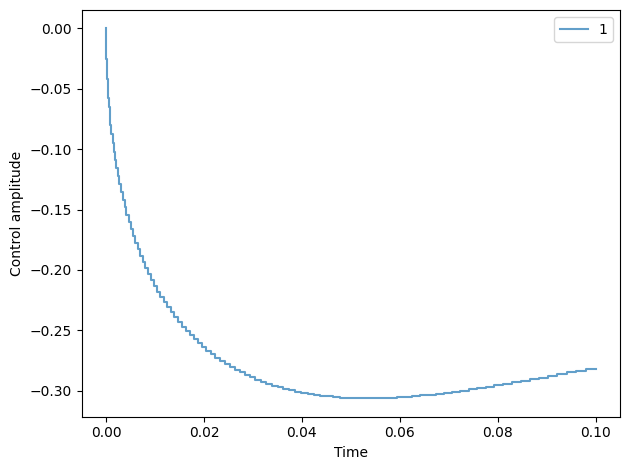

In [88]:
fig1 = plt.figure()
ax = fig1.add_subplot(1, 1, 1)

for i in range(len(H_c)):
    ax.step(
        result_grape.time,
        np.hstack((result_grape.final_amps[:, i], result_grape.final_amps[-1, i])),
        where="post",
        alpha=0.7,
        label=f"{i + 1}",
    )

ax.set_xlabel("Time")
ax.set_ylabel("Control amplitude")
ax.legend()
plt.tight_layout()
plt.show()

Временная зависимость фиделити для гамильтониана с оптимальным контролем и основным


In [80]:
evolution_grape = qutip.sesolve(
    [H_d] + [(H_c[i], result_grape.final_amps[:, i]) for i in range(len(H_c))],
    state_initial,
    tspan,
    options=qutip.Options(nsteps=1e6),
    progress_bar=TqdmProgressBar()
)

100%|██████████| 101/101 [00:00<00:00, 4519.82it/s]


In [81]:
evolution_drift = qutip.sesolve(
    H_d,
    state_initial,
    tspan,
    progress_bar=TqdmProgressBar()
)

100%|██████████| 101/101 [00:00<00:00, 5965.70it/s]


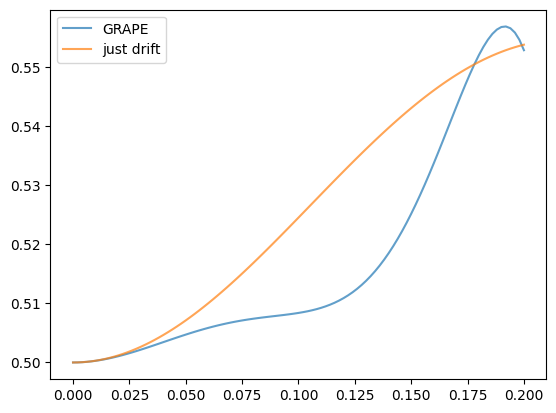

In [82]:
plt.plot(
    tspan,
    [qutip.metrics.fidelity(psi_target, psi) for psi in evolution_grape.states],
    alpha=0.7,
    label="GRAPE",
)

plt.plot(
    tspan,
    [qutip.metrics.fidelity(psi_target, psi) for psi in evolution_drift.states],
    alpha=0.7,
    label="just drift",
)

plt.legend()